In [189]:
import pandas as pd
import time
from nba_api.stats.endpoints import leaguedashplayerstats
from nba_api.stats.endpoints import leaguedashplayerbiostats
from nba_api.stats.endpoints import draftcombineplayeranthro, draftcombinestats
from nba_api.stats.endpoints import leaguedashplayerstats
from basketball_reference_web_scraper import client

### data extraction from nba-api

In [190]:
all_stats = []

print("=== מתחיל שאיבת טבלת ביצועים וסטטיסטיקות ===")

for start_year in range(1990, 2026):
    season_str = f"{start_year}-{str(start_year + 1)[2:]}"
    try:
        # שאיבת הנתונים לעונה הנוכחית בלולאה
        df = leaguedashplayerstats.LeagueDashPlayerStats(season=season_str, per_mode_detailed='PerGame').get_data_frames()[0]
        df['Season'] = season_str
        all_stats.append(df)
        
        # הדפסת כמות הנתונים שנשאבו בהצלחה בשנה זו
        print(f"[עונת {season_str}] הצלחה! נשאבו {len(df)} שורות של שחקנים לטבלת הביצועים.")
        
    except Exception as e:
        print(f"[עונת {season_str}] שגיאה בשאיבה: {e}")
        
    # השהייה של 2 שניות למניעת חסימות
    time.sleep(2.0)

# איחוד ושמירה של הטבלה הראשונה
final_stats_df = pd.concat(all_stats, ignore_index=True)
final_stats_df.to_csv("nba_35_years_PERFORMANCE_STATS.csv", index=False)
print(f"\n=== סיום! קובץ 1 נשמר בהצלחה. סך הכל שורות בדאטאסט: {len(final_stats_df)} ===")

=== מתחיל שאיבת טבלת ביצועים וסטטיסטיקות ===
[עונת 1990-91] הצלחה! נשאבו 0 שורות של שחקנים לטבלת הביצועים.


KeyboardInterrupt: 

In [ ]:
all_bios = []

print("=== מתחיל שאיבת טבלת נתונים פיזיים וביומטריים ===")

for start_year in range(1990, 2026):
    season_str = f"{start_year}-{str(start_year + 1)[2:]}"
    try:
        # שאיבת הנתונים לעונה הנוכחית בלולאה
        df = leaguedashplayerbiostats.LeagueDashPlayerBioStats(season=season_str).get_data_frames()[0]
        df['Season'] = season_str
        
        all_bios.append(df)
        
        # הדפסת כמות הנתונים שנשאבו בהצלחה בשנה זו
        print(f"[עונת {season_str}] הצלחה! נשאבו {len(df)} שורות של שחקנים לטבלת הנתונים הפיזיים.")
        
    except Exception as e:
        print(f"[עונת {season_str}] שגיאה בשאיבה: {e}")
        
    # השהייה של 2 שניות למניעת חסימות
    time.sleep(2.0)

# איחוד ושמירה של הטבלה השנייה
final_bios_df = pd.concat(all_bios, ignore_index=True)
final_bios_df.to_csv("nba_35_years_PHYSICAL_BIO.csv", index=False)
print(f"\n=== סיום! קובץ 2 נשמר בהצלחה. סך הכל שורות בדאטאסט: {len(final_bios_df)} ===")

=== מתחיל שאיבת טבלת נתונים פיזיים וביומטריים ===
[עונת 1990-91] הצלחה! נשאבו 0 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 1991-92] הצלחה! נשאבו 0 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 1992-93] הצלחה! נשאבו 0 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 1993-94] הצלחה! נשאבו 0 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 1994-95] הצלחה! נשאבו 0 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 1995-96] הצלחה! נשאבו 0 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 1996-97] הצלחה! נשאבו 441 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 1997-98] הצלחה! נשאבו 439 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 1998-99] הצלחה! נשאבו 440 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 1999-00] הצלחה! נשאבו 439 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 2000-01] הצלחה! נשאבו 441 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 2001-02] הצלחה! נשאבו 440 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 2002-03] הצלחה! נשאבו 428 שורות של שחקנים לטבלת הנתונים הפיזיים.
[עונת 2003-04] הצלחה! נשאבו 442 שורות ש

C:\Users\AI\AppData\Local\Temp\ipykernel_25980\1857134270.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_bios_df = pd.concat(all_bios, ignore_index=True)


In [ ]:
all_anthro_data = []
all_athletic_data = []

print("=== מתחיל שאיבת נתוני Draft Combine היסטוריים ===")

# הלולאה מעודכנת להתחיל מ-1993 כפי שניסית
for start_year in range(1990, 2026):
    season_str = f"{start_year}-{str(start_year + 1)[2:]}"
    print(f"\n[+] מעבד את שנת הדראפט: {start_year}...")
    
    # --- חלק 1: שאיבת מדידות גוף (אנתרופומטריה) ---
    try:
        # כאן שם הפרמטר נשאר season_year
        api_anthro = draftcombineplayeranthro.DraftCombinePlayerAnthro(season_year=season_str)
        df_anthro = api_anthro.get_data_frames()[0]
        
        if not df_anthro.empty:
            df_anthro['Draft_Year'] = start_year 
            all_anthro_data.append(df_anthro)
            print(f"   -> קובץ 1 (מדידות): נשאבו {len(df_anthro)} שורות.")
        else:
            print(f"   -> קובץ 1 (מדידות): לא נמצאו נתונים לשנה זו.")
    except Exception as e:
        print(f"   [X] שגיאה בשאיבת מדידות גוף: {e}")
        
    time.sleep(1.5) 
    
    # --- חלק 2: שאיבת מבחנים אתלטיים (כושר וקפיצה) ---
    try:
        api_athletic = draftcombinestats.DraftCombineStats(season_all_time=season_str)
        df_athletic = api_athletic.get_data_frames()[0]
        
        if not df_athletic.empty:
            df_athletic['Draft_Year'] = start_year 
            all_athletic_data.append(df_athletic)
            print(f"   -> קובץ 2 (מבחנים אתלטיים): נשאבו {len(df_athletic)} שורות.")
        else:
            print(f"   -> קובץ 2 (מבחנים אתלטיים): לא נמצאו נתונים לשנה זו.")
    except Exception as e:
        print(f"   [X] שגיאה בשאיבת מבחנים אתלטיים: {e}")
        
    time.sleep(2.5)

# --- איחוד ושמירה ---
print("\n[ * ] שומר את הקבצים...")
if all_anthro_data:
    pd.concat(all_anthro_data, ignore_index=True).to_csv("nba_draft_combine_ANTHRO.csv", index=False)
if all_athletic_data:
    pd.concat(all_athletic_data, ignore_index=True).to_csv("nba_draft_combine_ATHLETIC_STATS.csv", index=False)
print("=== סיום התהליך! שני הקבצים נשמרו בהצלחה. ===")

=== מתחיל שאיבת נתוני Draft Combine היסטוריים ===

[+] מעבד את שנת הדראפט: 1990...
   -> קובץ 1 (מדידות): לא נמצאו נתונים לשנה זו.
   -> קובץ 2 (מבחנים אתלטיים): לא נמצאו נתונים לשנה זו.

[+] מעבד את שנת הדראפט: 1991...
   -> קובץ 1 (מדידות): לא נמצאו נתונים לשנה זו.
   -> קובץ 2 (מבחנים אתלטיים): לא נמצאו נתונים לשנה זו.

[+] מעבד את שנת הדראפט: 1992...
   -> קובץ 1 (מדידות): לא נמצאו נתונים לשנה זו.
   -> קובץ 2 (מבחנים אתלטיים): לא נמצאו נתונים לשנה זו.

[+] מעבד את שנת הדראפט: 1993...
   -> קובץ 1 (מדידות): לא נמצאו נתונים לשנה זו.
   -> קובץ 2 (מבחנים אתלטיים): לא נמצאו נתונים לשנה זו.

[+] מעבד את שנת הדראפט: 1994...
   -> קובץ 1 (מדידות): לא נמצאו נתונים לשנה זו.
   -> קובץ 2 (מבחנים אתלטיים): לא נמצאו נתונים לשנה זו.

[+] מעבד את שנת הדראפט: 1995...
   -> קובץ 1 (מדידות): לא נמצאו נתונים לשנה זו.
   -> קובץ 2 (מבחנים אתלטיים): לא נמצאו נתונים לשנה זו.

[+] מעבד את שנת הדראפט: 1996...
   -> קובץ 1 (מדידות): לא נמצאו נתונים לשנה זו.
   -> קובץ 2 (מבחנים אתלטיים): לא נמצאו נתונים 

C:\Users\AI\AppData\Local\Temp\ipykernel_25980\1223952763.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(all_anthro_data, ignore_index=True).to_csv("nba_draft_combine_ANTHRO.csv", index=False)
C:\Users\AI\AppData\Local\Temp\ipykernel_25980\1223952763.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(all_athletic_data, ignore_index=True).to_csv("nba_draft_combine_ATHLETIC_STATS.csv", index=False)


In [ ]:
all_gleague_seasons = []

print("=== מתחיל שאיבת היסטוריית ה-G-League (ממוצעים עונתיים) ===")

# רצים משנת 2007 (עונת 2007-08) ועד 2025 (עונת 2025-26)
for start_year in range(2007, 2026):
    end_year_short = str(start_year + 1)[2:]
    season_str = f"{start_year}-{end_year_short}"
    
    print(f"\n[+] שואב נתוני G-League עבור עונת {season_str}...")
    
    try:
        # פנייה ל-API עם מזהה הליגה '20' שחוסך מאיתנו לרוץ שחקן-שחקן
        gleague_api = leaguedashplayerstats.LeagueDashPlayerStats(
            season=season_str,
            league_id_nullable='20',  # '20' הוא המזהה הייחודי של ה-G-League
            per_mode_detailed='PerGame'  # משיכת ממוצעים למשחק
        )
        
        df_season = gleague_api.get_data_frames()[0]
        
        if not df_season.empty:
            # חובה: הוספת עמודת העונה כדי שנדע מאיזו שנה כל שורה בדאטאסט הסופי
            df_season['Season'] = season_str
            all_gleague_seasons.append(df_season)
            
            # הדפסת כמות הנתונים שנשאבו בהצלחה בשנה זו
            print(f"   -> הצלחה! נשאבו {len(df_season)} שורות של שחקני G-League.")
        else:
            print(f"   -> לא נמצאו נתונים עבור עונת {season_str}.")
            
    except Exception as e:
        print(f"   [X] שגיאה בשאיבת עונת {season_str}: {e}")
        
    # השהייה של 2.5 שניות בין עונה לעונה למניעת חסימות IP
    time.sleep(2.5)

# --- איחוד סופי ושמירה לקובץ נפרד ---
print("\n[ * ] מאחד את כל עונות ה-G-League לטבלת מאסטר אחת...")

if all_gleague_seasons:
    final_gleague_df = pd.concat(all_gleague_seasons, ignore_index=True)
    
    # שמירה לקובץ CSV עצמאי לחלוטין
    final_gleague_df.to_csv("gleague_historical_PERFORMANCE_STATS.csv", index=False)
    
    print(f"=== סיום התהליך! הקובץ נשמר: gleague_historical_PERFORMANCE_STATS.csv ===")
    print(f"סך הכל שורות היסטוריות שנאספו מליגת הפיתוח: {len(final_gleague_df)}")
else:
    print("[X] לא נאספו נתונים. ודא שאין חסימת אינטרנט ושם ה-API זמין.")

=== מתחיל שאיבת היסטוריית ה-G-League (ממוצעים עונתיים) ===

[+] שואב נתוני G-League עבור עונת 2007-08...
   -> הצלחה! נשאבו 242 שורות של שחקני G-League.

[+] שואב נתוני G-League עבור עונת 2008-09...
   -> הצלחה! נשאבו 273 שורות של שחקני G-League.

[+] שואב נתוני G-League עבור עונת 2009-10...
   -> הצלחה! נשאבו 274 שורות של שחקני G-League.

[+] שואב נתוני G-League עבור עונת 2010-11...
   -> הצלחה! נשאבו 281 שורות של שחקני G-League.

[+] שואב נתוני G-League עבור עונת 2011-12...
   -> הצלחה! נשאבו 368 שורות של שחקני G-League.

[+] שואב נתוני G-League עבור עונת 2012-13...
   -> הצלחה! נשאבו 294 שורות של שחקני G-League.

[+] שואב נתוני G-League עבור עונת 2013-14...
   -> הצלחה! נשאבו 325 שורות של שחקני G-League.

[+] שואב נתוני G-League עבור עונת 2014-15...
   -> הצלחה! נשאבו 360 שורות של שחקני G-League.

[+] שואב נתוני G-League עבור עונת 2015-16...
   -> הצלחה! נשאבו 367 שורות של שחקני G-League.

[+] שואב נתוני G-League עבור עונת 2016-17...
   -> הצלחה! נשאבו 413 שורות של שחקני G-League.



In [ ]:
all_advanced_data = []

print("=== מתחיל שאיבת מדדים מתקדמים היסטוריים (1996-97 עד העונה הנוכחית) ===")

# עונת 1996-97 מסתיימת ב-1997. העונה הנוכחית (2025-26) מסתיימת ב-2026.
# כדי לכלול את 2026 ב-range, נגדיר את הגבול העליון כ-2027.
for year in range(1997, 2027):
    # בניית מחרוזת העונה לצורך סימון בטבלה (למשל: '1996-97', '2025-26')
    start_year = year - 1
    end_year_short = str(year)[2:]
    season_str = f"{start_year}-{end_year_short}"
    
    print(f"\n[+] שואב מדדים מתקדמים עבור עונת {season_str} (שנת סיום: {year})...")
    
    try:
        # שאיבת טבלת המדדים המתקדמים מהאתר עבור אותה שנה
        raw_data = client.players_advanced_season_totals(season_end_year=year)
        df_season = pd.DataFrame(raw_data)
        
        if not df_season.empty:
            # הוספת עמודת עונה כדי שנוכל להבדיל בין השנים השונות בתוך הטבלה המאוחדת
            df_season['Season'] = season_str
            all_advanced_data.append(df_season)
            
            # הדפסת כמות הנתונים שנשאבו בהצלחה בשנה זו
            print(f"   -> הצלחה! נשאבו {len(df_season)} שורות של שחקנים.")
        else:
            print(f"   -> לא נמצאו נתונים עבור שנת {year}.")
            
    except Exception as e:
        print(f"   [X] שגיאה בשאיבת עונת {season_str}: {e}")
        
    # חוק ברזל: השהייה קריטית של 4.0 שניות בין שנה לשנה!
    # האתר חוסם אוטומטית כתובות IP שמבצעות יותר מ-20 בקשות בדקה.
    time.sleep(4.0)

# --- שלב האיחוד הסופי והשמירה לטבלה אחת ---
print("\n[ * ] מאחד את כל העונות ההיסטוריות לטבלת מאסטר אחת גדולה...")

if all_advanced_data:
    # איחוד כל ה-DataFrames ברשימה לטבלה אחת ארוכה ברצף
    final_advanced_df = pd.concat(all_advanced_data, ignore_index=True)
    
    # שמירה לקובץ CSV אחד מאוחד
    output_filename = "nba_advanced_stats_1996_to_current.csv"
    final_advanced_df.to_csv(output_filename, index=False)
    
    print(f"=== סיום התהליך בהצלחה! ===")
    print(f"הקובץ המאוחד נשמר בשם: {output_filename}")
    print(f"סך הכל שורות מדדים מתקדמים שנאספו מכל השנים: {len(final_advanced_df)}")
else:
    print("[X] לא נאספו נתונים. ודא שחיבור האינטרנט תקין ושאין חסימת IP מצד האתר.")

=== מתחיל שאיבת מדדים מתקדמים היסטוריים (1996-97 עד העונה הנוכחית) ===

[+] שואב מדדים מתקדמים עבור עונת 1996-97 (שנת סיום: 1997)...
   -> הצלחה! נשאבו 511 שורות של שחקנים.

[+] שואב מדדים מתקדמים עבור עונת 1997-98 (שנת סיום: 1998)...
   -> הצלחה! נשאבו 494 שורות של שחקנים.

[+] שואב מדדים מתקדמים עבור עונת 1998-99 (שנת סיום: 1999)...
   -> הצלחה! נשאבו 474 שורות של שחקנים.

[+] שואב מדדים מתקדמים עבור עונת 1999-00 (שנת סיום: 2000)...
   -> הצלחה! נשאבו 468 שורות של שחקנים.

[+] שואב מדדים מתקדמים עבור עונת 2000-01 (שנת סיום: 2001)...
   -> הצלחה! נשאבו 490 שורות של שחקנים.

[+] שואב מדדים מתקדמים עבור עונת 2001-02 (שנת סיום: 2002)...
   -> הצלחה! נשאבו 470 שורות של שחקנים.

[+] שואב מדדים מתקדמים עבור עונת 2002-03 (שנת סיום: 2003)...
   -> הצלחה! נשאבו 456 שורות של שחקנים.

[+] שואב מדדים מתקדמים עבור עונת 2003-04 (שנת סיום: 2004)...
   -> הצלחה! נשאבו 517 שורות של שחקנים.

[+] שואב מדדים מתקדמים עבור עונת 2004-05 (שנת סיום: 2005)...
   -> הצלחה! נשאבו 526 שורות של שחקנים.

[+] שואב מ

## data exploration and preprocessing

### our datasets: 

* `g_league_Stats` - contains stats of all g league players from 2007-08 season to 2025-26 season
* `combine_athletic_stats` - contains draft combine results for nba players draftet from 2000 to 2025 nba draft
* `nba_player_stats` - contains nba player season stats from 1996-97 season to 2025-2026 nba season
* `nba_advance_player_stats` - contains nba player season advance statistics (such as win-shares) from 1996-97 season to 2025-2026 nba season

In [199]:
#gathering all datasets
g_league_stats = pd.read_csv('gleague_historical_PERFORMANCE_STATS.csv')
combine_athletic_stats = pd.read_csv('nba_draft_combine_ATHLETIC_STATS.csv')
nba_player_stats = pd.read_csv('nba_35_years_PERFORMANCE_STATS.csv')
nba_advance_player_stats = pd.read_csv('nba_advanced_stats_1996_to_current.csv')

In [200]:
player_heights_and_weights = pd.read_csv('nba_players_35_years_stats_and_bio.csv')
player_heights_and_weights = player_heights_and_weights.loc[:, ['PLAYER_ID', 'PLAYER_WEIGHT', 'PLAYER_HEIGHT_INCHES', 'Season']]

# adding height and weight columns to stat data
nba_player_stats = nba_player_stats.merge(right = player_heights_and_weights, how='inner', on=['PLAYER_ID', 'Season'])

C:\Users\AI\AppData\Local\Temp\ipykernel_26368\4095664303.py:1: DtypeWarning: Columns (68) have mixed types. Specify dtype option on import or set low_memory=False.
  player_heights_and_weights = pd.read_csv('nba_players_35_years_stats_and_bio.csv')


In [201]:
stats_columns = [
    'PLAYER_NAME', 'Season', 'AGE', 'MIN', 
    'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 
    'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'PF', 'PTS'
]

g_league_stats = g_league_stats.loc[:, stats_columns]
nba_player_stats = nba_player_stats.loc[:, stats_columns + ['PLAYER_WEIGHT', 'PLAYER_HEIGHT_INCHES']]

#### we have no missing values in our datadet

#### normalizing all player data to per 36 to get a consistent view on archetypes

In [202]:
nba_player_stats['player'] = nba_player_stats['PLAYER_NAME'] + ' ' + nba_player_stats['Season']
stats_cols = ['FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 
            'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'PTS', 'MIN']

pure_player_stats = nba_player_stats.copy()

multiplier = 36 / nba_player_stats['MIN']

nba_player_stats.loc[:, stats_cols] = nba_player_stats.loc[:, stats_cols].multiply(multiplier, axis=0)
nba_player_stats.drop(['MIN', 'PLAYER_NAME', 'Season'], axis = 1, inplace=True)

#### now we have extreme values which we will remove using IQR method

#### doing such filtering makes a lot of sence as the players that are the most affected by the per 36 normalization of stats are "end of the beanch" players who didn't recieve plaing time in the first place
#### thus using them for cluster profiling isn't a great idea as they poluts the data

In [203]:
numeric_cols = nba_player_stats.select_dtypes(include=['number']).columns

Q1 = nba_player_stats[numeric_cols].quantile(0.25)
Q3 = nba_player_stats[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = ((nba_player_stats[numeric_cols] >= lower_bound) & (nba_player_stats[numeric_cols] <= upper_bound)).all(axis=1)

stats_filtered = nba_player_stats[mask]

print(f"number of rows before filtering: {nba_player_stats.shape[0]}")
print(f"number of rows after IQR filtering: {stats_filtered.shape[0]}")

nba_player_stats = nba_player_stats[mask]

number of rows before filtering: 14569
number of rows after IQR filtering: 10839


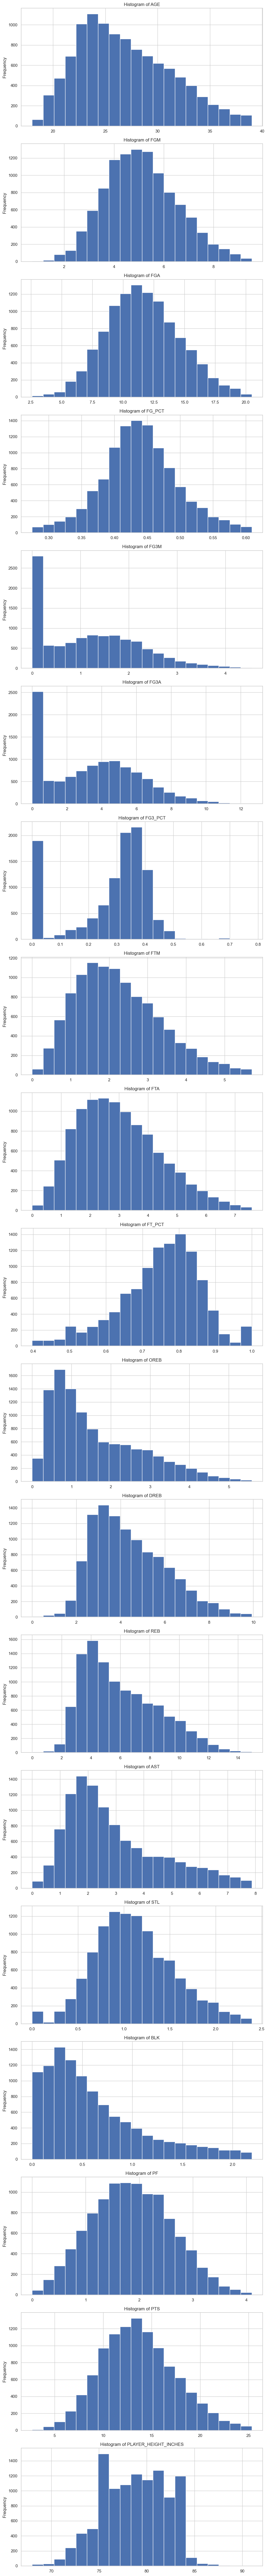

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_df = nba_player_stats.select_dtypes(include=['number'])

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=numerical_df.shape[1], ncols=1, figsize=(10, 5 * numerical_df.shape[1]), sharex=False)

for i, col in enumerate(numerical_df.columns):
    numerical_df[col].plot(kind='hist', ax=axes[i], bins=20)
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### creating clustring models: Kmean, GMM (Kmeans with probabilities)

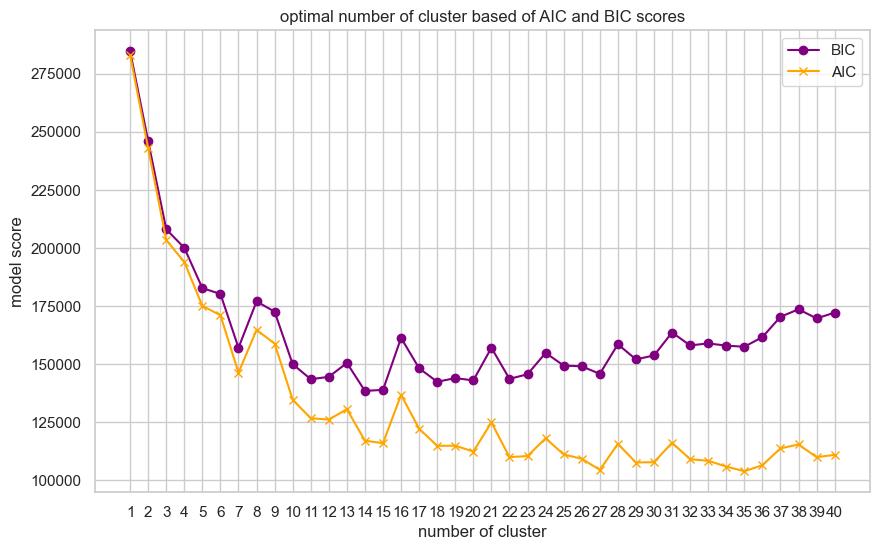

In [205]:
# imlementing GMM and chosing optimal number of clusters
from sklearn.mixture import GaussianMixture

numeric_cols = nba_player_stats.select_dtypes(include=['number']).columns
df = nba_player_stats.loc[:, numeric_cols]

bic_scores = []
aic_scores = []
n_components_range = range(1, 41)

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(numerical_df)
    
    bic_scores.append(gmm.bic(df))
    aic_scores.append(gmm.aic(df))

plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic_scores, marker='o', label='BIC', color='purple')
plt.plot(n_components_range, aic_scores, marker='x', label='AIC', color='orange')

plt.title('optimal number of cluster based of AIC and BIC scores')
plt.xlabel('number of cluster')
plt.ylabel('model score')
plt.xticks(n_components_range)
plt.legend()
plt.grid(True)
plt.show()

Evaluating K-Means models and calculating metrics...


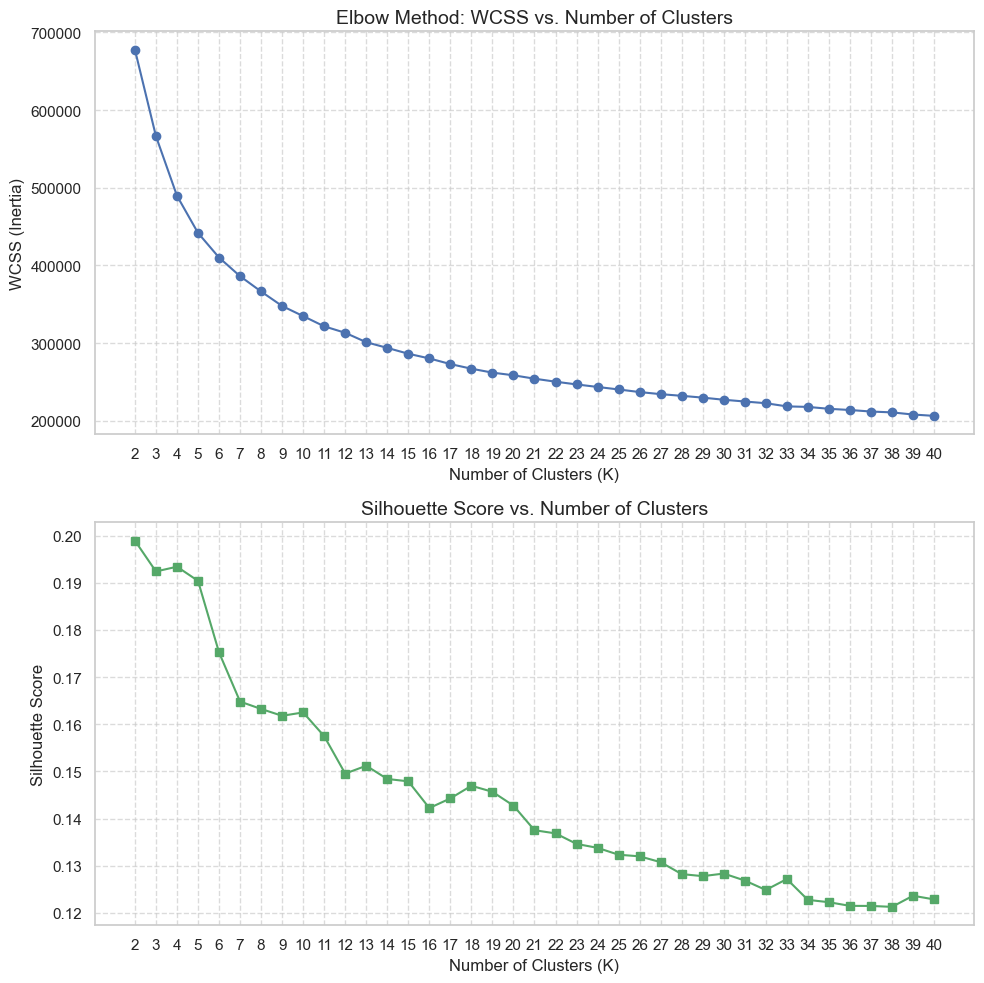

In [206]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Assuming 'df' is your preprocessed, numeric-only DataFrame
# We test K values from 2 to 20 (Silhouette score requires at least 2 clusters)
k_values = range(2, 41)

wcss_scores = []
silhouette_scores = []

print("Evaluating K-Means models and calculating metrics...")

for k in k_values:
    # 1. Initialize and fit the K-Means model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(df)
    
    # 2. Store the metrics
    wcss_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df, cluster_labels))

# 3. Plotting the results
# Create a figure with 2 subplots arranged vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# --- Plot 1: WCSS (Elbow Method) ---
ax1.plot(k_values, wcss_scores, marker='o', linestyle='-', color='b')
ax1.set_title('Elbow Method: WCSS vs. Number of Clusters', fontsize=14)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', fontsize=12)
ax1.set_xticks(k_values)
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Silhouette Score ---
ax2.plot(k_values, silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_title('Silhouette Score vs. Number of Clusters', fontsize=14)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_xticks(k_values)
ax2.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap and display the plots
plt.tight_layout()
plt.show()

##### we'll choose 22 clusters as it's the elbow point of kmeans by silhouette score, meaning we will have 22 archtyps of players. we will analyze those clusters to make the player archtyps for out app

### cluster profiling

In [207]:
gmm = GaussianMixture(n_components=22, random_state=42)
gmm.fit(numerical_df)

nba_player_stats['cluster'] = gmm.predict(numerical_df)
nba_player_stats['cluster_confidence'] = gmm.predict_proba(numerical_df).max(axis=1)
nba_player_stats

,AGE,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,...,AST,STL,BLK,PF,PTS,PLAYER_WEIGHT,PLAYER_HEIGHT_INCHES,player,cluster,cluster_confidence
0,33.0,3.348837,6.936877,0.483,0.000000,0.239203,0.050,1.794020,2.870432,0.650,...,0.956811,0.956811,0.239203,1.7,8.611296,225,81.0,A.C. Green 1996-97,6,0.999996
1,24.0,3.306122,8.081633,0.411,0.918367,2.204082,0.398,2.020408,2.387755,0.836,...,3.489796,1.653061,0.551020,1.6,9.551020,209,77.0,Aaron McKie 1996-97,7,0.828587
2,25.0,5.505882,9.529412,0.574,0.000000,0.000000,0.000,2.117647,3.176471,0.673,...,1.058824,1.058824,1.905882,2.2,13.129412,225,81.0,Aaron Williams 1996-97,13,0.999999
3,27.0,4.754717,12.905660,0.374,0.000000,0.339623,0.000,3.735849,6.113208,0.643,...,1.358491,1.018868,2.037736,1.3,13.584906,240,83.0,Acie Earl 1996-97,21,0.999941
4,27.0,3.162162,6.324324,0.513,0.000000,0.000000,0.000,2.675676,4.135135,0.689,...,1.216216,1.216216,0.486486,1.6,9.243243,241,81.0,Adam Keefe 1996-97,13,0.999995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14561,21.0,5.785714,12.857143,0.455,2.250000,6.267857,0.368,1.446429,2.089286,0.644,...,1.767857,1.446429,0.803571,2.2,15.428571,200.0,80.0,Zaccharie Risacher 2025-26,10,0.994118
14562,28.0,7.239130,12.521739,0.578,1.760870,4.108696,0.429,2.739130,3.913043,0.700,...,2.934783,0.391304,0.782609,1.8,18.978261,240.0,81.0,Zach Collins 2025-26,9,0.897491
14564,31.0,7.681529,16.050955,0.479,2.866242,7.452229,0.390,3.668790,4.127389,0.880,...,2.636943,0.802548,0.343949,2.1,22.012739,200.0,77.0,Zach LaVine 2025-26,18,0.806647
14565,25.0,4.200000,8.700000,0.470,0.900000,3.000000,0.259,2.100000,2.400000,0.773,...,1.800000,0.900000,1.500000,1.4,11.100000,240.0,82.0,Zeke Nnaji 2025-26,14,0.999489


In [212]:
import pandas as pd

def analyze_cluster(model_data, full_data, cluster_col, target_cluster, player_name_col, identifier_col='index', top_n=5, sort_by=None):
    """
    Analyzes a specific cluster's statistical profile and retrieves its top 
    representative players from the original dataset using a flexible identifier.

    Args:
        model_data (pd.DataFrame): The DataFrame containing the numeric data and cluster assignments.
        full_data (pd.DataFrame): The original DataFrame containing player names and actual stats.
        cluster_col (str): The name of the column holding the cluster assignments in model_data.
        target_cluster (int or str): The specific cluster label/ID to analyze.
        player_name_col (str): The column name in full_data containing the player names.
        identifier_col (str, optional): The column name used to link model_data and full_data. 
                                        If 'index', links by DataFrame index. Defaults to 'index'.
        top_n (int, optional): The number of top players to display. Defaults to 5.
        sort_by (str or list, optional): A single column name (str) or a list of column names (list)
                                        to sort the top players by. Defaults to None.

    Returns:
        pd.DataFrame: A summary table displaying the cluster's mean, population mean, 
                    and the percentage difference for each numeric feature.
    """
    # 1. Filter data for the specific cluster
    cluster_data = model_data[model_data[cluster_col] == target_cluster]
    
    # 2. Calculate means
    cluster_mean = cluster_data.mean(numeric_only=True)
    population_mean = model_data.mean(numeric_only=True)
    
    # 3. Create summary dataframe
    summary_df = pd.DataFrame({
        'Cluster_Mean': cluster_mean,
        'Population_Mean': population_mean
    })
    
    # 4. Calculate percentage difference and sort by absolute difference
    summary_df['Difference_%'] = ((summary_df['Cluster_Mean'] - summary_df['Population_Mean']) / summary_df['Population_Mean'] * 100).round(1)
    summary_df['Abs_Diff'] = summary_df['Difference_%'].abs()
    summary_df = summary_df.sort_values(by='Abs_Diff', ascending=False).drop(columns=['Abs_Diff'])
    
    # 5. Print basic cluster stats
    cluster_size = len(cluster_data)
    total_size = len(model_data)
    print(f"\n{'='*40}")
    print(f"--- Cluster {target_cluster} Profile ---")
    print(f"Cluster Size: {cluster_size} rows ({(cluster_size/total_size*100):.1f}% of population)\n")
    
    # 6. Retrieve players using the specified identifier method
    if identifier_col == 'index':
        players_in_cluster = full_data.loc[cluster_data.index]
    else:
        # Validate that the identifier column exists in both dataframes
        if identifier_col not in model_data.columns or identifier_col not in full_data.columns:
            print(f"Error: Identifier column '{identifier_col}' must exist in both model_data and full_data.")
            return summary_df
        
        # Extract unique IDs from the model data and filter the full data
        cluster_ids = cluster_data[identifier_col]
        players_in_cluster = full_data[full_data[identifier_col].isin(cluster_ids)]
    
    # 7. Sort and display top players
    if sort_by:
        sort_columns = [sort_by] if isinstance(sort_by, str) else sort_by
        
        if all(col in players_in_cluster.columns for col in sort_columns):
            top_players = players_in_cluster.sort_values(by=sort_columns, ascending=False).head(top_n)
            
            columns_to_print = [player_name_col] + sort_columns
            print(f"Top {top_n} Players (Sorted by {', '.join(sort_columns)}):")
            print(top_players[columns_to_print].to_string(index=False))
        else:
            print("Error: One or more sort columns not found in the data.")
    else:
        top_players = players_in_cluster.head(top_n)
        print(f"First {top_n} Players in Cluster:")
        print(top_players[[player_name_col]].to_string(index=False))
        
    print(f"{'='*40}\n")
    
    return summary_df

In [215]:
for cluster_num in sorted(nba_player_stats.cluster.unique()):
    profile_df = analyze_cluster(
        model_data=nba_player_stats, 
        full_data=pure_player_stats, 
        cluster_col='cluster',
        target_cluster=cluster_num, 
        player_name_col='player', 
        identifier_col='index',
        top_n=5, 
        sort_by=['PTS', 'REB', 'AST', 'STL', 'BLK', 'FG3_PCT', 'FG3M', 'FG_PCT', 'FGM'] 
    )    
    # printing 10 most distinct stats from the general population
    print(profile_df.head(10))


--- Cluster 0 Profile ---
Cluster Size: 149 rows (1.4% of population)

Top 5 Players (Sorted by PTS, REB, AST, STL, BLK, FG3_PCT, FG3M, FG_PCT, FGM):
                    player  PTS  REB  AST  STL  BLK  FG3_PCT  FG3M  FG_PCT  FGM
     Tracy McGrady 2000-01 26.8  7.5  4.6  1.5  1.5    0.355   0.8   0.457 10.2
Karl-Anthony Towns 2016-17 25.1 12.3  2.7  0.7  1.3    0.367   1.2   0.542  9.8
      Chris Webber 1999-00 24.5 10.5  4.6  1.6  1.7    0.284   0.4   0.483 10.0
      Chris Webber 2001-02 24.5 10.1  4.8  1.7  1.4    0.263   0.1   0.495  9.9
     Anthony Davis 2015-16 24.3 10.3  1.9  1.3  2.0    0.324   0.6   0.493  9.2

         Cluster_Mean  Population_Mean  Difference_%
cluster      0.000000        10.687610        -100.0
OREB         2.961403         1.627152          82.0
BLK          1.103119         0.616148          79.0
REB         10.064164         6.040177          66.6
FTA          4.821777         2.998241          60.8
DREB         7.098725         4.416783          60

## cluster analysis and architype assaignment (see cluster-statistics.txt for full statistical output):

### Cluster 0: Elite Scoring Playmaker Bigs
* **Top Prototypes:** Tracy McGrady (2000-01), Karl-Anthony Towns (2016-17), Chris Webber (1999-00, 2001-02), Anthony Davis (2015-16)[cite: 1].
* **Style Analysis:** This is an elite, high-impact group representing only 1.4% of the population. They are dominant frontcourt players (or oversized wings like early T-Mac) who excel at offensive rebounding (OREB is 82% above average) and rim protection (BLK is 79% above average). They draw heavy fouls and get to the line frequently (FTA +60.8%). 
* **Player Fit:** Players like Karl-Anthony Towns (16-17) and Anthony Davis (15-16) perfectly mirror this style by dominating the paint, securing double-digit rebounds (12.3 and 10.3 respectively), and acting as offensive hubs[cite: 1]. While they can shoot, their overall 3-point volume is historically lower than modern guards (FG3M is 49.6% below average).

### Cluster 1: Elite 3&D Connecting Wings
* **Top Prototypes:** Derrick White (2023-24), Lance Stephenson (2013-14), Mikal Bridges (2020-21), Grayson Allen (2023-24), Boris Diaw (2008-09).
* **Style Analysis:** The ultimate modern role players. They provide immense value through floor spacing and perimeter efficiency. Their 3-point percentage is 39.6% above the league average, and their 3-point makes are 62.3% above average. 
* **Player Fit:** Derrick White (23-24) and Mikal Bridges (20-21) exemplify this by taking high-efficiency threes (White shot 39.6%, Bridges 42.5%) while rarely relying on isolation plays that lead to free throws (Cluster FTA is 45.1% below average). They keep the ball moving and anchor the perimeter defense.

### Cluster 2: Low-Usage Defensive Anchors & Connectors
* **Top Prototypes:** Al Horford (2024-25), Metta World Peace (2010-11), Kyle Anderson (2017-18, 2018-19), Caleb Martin (2024-25).
* **Style Analysis:** High-IQ, low-maintenance glue guys. They don't command the ball (PTS are 34.3% below average, FGA 30.8% below average) but they play winning basketball. They shoot a respectable percentage from deep (+22.7% above average) to keep defenses honest.
* **Player Fit:** Kyle Anderson and late-career Al Horford fit this mold perfectly. They average low points (around 8-9 PPG), but they facilitate, defend multiple positions, and act as connective tissue for elite offenses without needing designed plays.

### Cluster 3: High-Volume Inefficient Floor Spacers
* **Top Prototypes:** Khyri Thomas (2020-21), Vander Blue (2014-15), Michael Porter Jr. (2021-22), Voshon Lenard (2004-05), Antoine Walker (2006-07).
* **Style Analysis:** Green-light shooters who prioritize volume over efficiency. This cluster takes a massive amount of threes (FG3A is 93.6% above average). However, their overall field goal percentage suffers greatly (-15.9% below average).
* **Player Fit:** Antoine Walker (06-07) is the historical poster child for this, but even a young MPJ in his injury-riddled 21-22 season fell into this trap. They hoist shots from deep to space the floor but often struggle to convert efficiently or contribute defensively (Steals and Blocks are below average).

### Cluster 4: Interior Scrappers & Slashing Forwards
* **Top Prototypes:** Chris Webber (1998-99), Shawn Marion (2001-02), Josh Childress (2006-07), Michael Kidd-Gilchrist (2015-16), Taj Gibson (2017-18).
* **Style Analysis:** High-energy, physical forwards who live inside the arc. They are elite at generating extra possessions via offensive rebounds (+64.1%) and provide strong weak-side blocking (+57.2%). They provide almost zero floor spacing (FG3M is 68.9% below average).
* **Player Fit:** Shawn Marion (01-02) and Michael Kidd-Gilchrist (15-16) embody this relentless slashing style. They cut off-ball, crash the glass hard (averaging 6.4 to 13.0 rebounds), and finish in the paint rather than settling for jumpers.

### Cluster 5: High-Tempo Playmaking Guards
* **Top Prototypes:** Baron Davis (2001-02), Quentin Richardson (2003-04), Kennedy Chandler (2025-26), Tre Jones (2025-26), Kerry Kittles (1998-99).
* **Style Analysis:** Pace-pushing floor generals and opportunistic guards. Their primary strengths are setting up teammates (AST +23.6%) and jumping passing lanes (STL +18.3%). They lack size, resulting in very low offensive rebounding (-37.3%) and shot-blocking (-34.1%).
* **Player Fit:** Baron Davis (01-02) with 8.5 assists and 2.1 steals is the classic representation. They excel in transition, dictating the tempo of the game and relying on quick hands defensively rather than verticality.

### Cluster 6: Old-School Post-Up & Midrange Bigs
* **Top Prototypes:** LaMarcus Aldridge (2010-11, 2011-12, 2013-14), Al Jefferson (2008-09), Antonio McDyess (1998-99).
* **Style Analysis:** The traditional back-to-the-basket and mid-range big men. They are exceptional rebounders (+39.3%) and interior defenders (+57.5% in blocks). They draw fouls effectively but completely ignore the 3-point line (FG3M is literally 0, -100% below average).
* **Player Fit:** LaMarcus Aldridge and Al Jefferson are the undisputed kings of this cluster. They averaged over 21 points and nearly 10+ rebounds relying entirely on post-footwork, turnaround jumpers, and hook shots without ever stepping behind the arc.

### Cluster 7: Elite High-Usage Scoring Wings
* **Top Prototypes:** Kobe Bryant (2009-10), Glen Rice (1996-97), Mitch Richmond (1996-97), Vince Carter (1999-00), Gilbert Arenas (2004-05).
* **Style Analysis:** Primary perimeter scoring options. These are the go-to guys who command defensive attention. They score in bunches (PTS +14.4%), shoot well from deep (FG3M +63.9%), and facilitate for others (AST +22.5%). 
* **Player Fit:** Kobe Bryant (09-10) and prime Vince Carter (99-00) define this role. They handle the ball heavily, take tough contested jumpers, and act as the offensive engines for their teams, though they conserve energy on the offensive glass (-47.2% OREB).

### Cluster 8: Traditional Playmaking Point Guards
* **Top Prototypes:** Terrell Brandon (1996-97), Jason Terry (2001-02), Wally Szczerbiak (2005-06), Michael Dickerson (1999-00), Mo Williams (2008-09).
* **Style Analysis:** Pass-first point guards (and secondary creators). They excel at running half-court sets, leading to high assist numbers (+56.6%). They are also reliable catch-and-shoot threats (FG3_PCT +30.6%). 
* **Player Fit:** Terrell Brandon (96-97) and Mo Williams (08-09) reflect this archetype. They average around 17-19 points and 4-6 assists. They navigate pick-and-rolls brilliantly but are undersized, meaning their interior defensive impact (Blocks -63.7%) is practically non-existent.

### Cluster 9: Elite Modern Two-Way Stretch Bigs
* **Top Prototypes:** Jaren Jackson Jr. (2023-24), Shawn Marion (2002-03, 2005-06), Dirk Nowitzki (2003-04), Rashard Lewis (2004-05).
* **Style Analysis:** Highly coveted "unicorn" profiles. They combine elite rim protection (BLK +53.1%) with high-volume perimeter shooting (FG3M +41.2%, FG3_PCT +30.2%). They also secure defensive boards efficiently (DREB +40.0%).
* **Player Fit:** Jaren Jackson Jr. (23-24) with 1.6 blocks and 1.8 made threes, and Dirk Nowitzki (03-04) with elite spacing and scoring. They stretch the opposing defense out to the perimeter on offense while anchoring their own team's defense in the paint.

### Cluster 10: Elite Spot-Up & Transition Sharpshooters
* **Top Prototypes:** Rashard Lewis (2001-02, 2008-09), Gary Harris (2017-18), OG Anunoby (2022-23), Morris Peterson (2005-06).
* **Style Analysis:** Pure snipers. Their defining trait is massive 3-point volume and efficiency (FG3M +92.3%, FG3_PCT +38.2%). They are play-finishers rather than play-creators (AST -34.7%, FTA -36.9%).
* **Player Fit:** Rashard Lewis during his Magic days (08-09) and OG Anunoby (22-23) show how this style operates. They spot up in the corners, run the wings in transition, and punish defenses that collapse into the paint, rarely dribbling to create their own shot.

### Cluster 11: High-Volume Bench Sparkplug Guards
* **Top Prototypes:** CJ McCollum (2021-22), Payton Pritchard (2025-26), Bogdan Bogdanović (2020-21, 2023-24), Reggie Jackson (2021-22).
* **Style Analysis:** Microwave scorers who light it up from beyond the arc. They have the highest 3-point attempt rate in the dataset (FG3A +135.9%, FG3M +145.4%). They are offensive catalysts.
* **Player Fit:** Bogdan Bogdanović and Payton Pritchard enter the game to do one thing: shoot. They provide instant offense and gravity, though their lack of size hurts their rebounding (REB -32.2%) and interior defense.

### Cluster 12: Low-Usage Inefficient Table-Setters
* **Top Prototypes:** Zavier Simpson (2021-22), Chris Duhon (2009-10), Mahmoud Abdul-Rauf (1997-98), DeShawn Stevenson (2008-09), Frank Mason III (2020-21).
* **Style Analysis:** Backup guards who focus strictly on running the offense safely. Their only above-average metric is assists (+60.0%). They are heavily detrimental as scorers (PTS -30.9%, FGM -29.3%) and shoot poorly.
* **Player Fit:** Chris Duhon (09-10) is the prototypical game manager here. He brings the ball up, calls the play, and passes it off. They lack the burst to finish at the rim or get to the foul line (-47.6% FTA).

### Cluster 13: Elite Glass-Cleaning Paint Beasts
* **Top Prototypes:** Carlos Boozer (2006-07, 2007-08), Antonio McDyess (2000-01), Brook Lopez (2010-11), Elton Brand (2000-01).
* **Style Analysis:** Absolute bullies in the paint. They generate massive second-chance opportunities (OREB +99.1%) and secure the defensive glass (+34.4%). They also block shots at a high rate (+81.0%).
* **Player Fit:** Peak Carlos Boozer and Elton Brand defined this era of basketball. They averaged 20+ points and 10+ rebounds exclusively through put-backs, pick-and-rolls, and post-ups. They have exactly zero 3-point attempts.

### Cluster 14: Balanced Utility Role Players
* **Top Prototypes:** Latrell Sprewell (1997-98), Shawn Marion (2003-04), Derrick Coleman (1997-98), Paul Pierce (1998-99), Derrick White (2025-26).
* **Style Analysis:** "Jack of all trades, master of none" wings and forwards. They do a little bit of everything: decent spacing (FG3_PCT +14.8%), good perimeter defense (STL +8.6%), but they are secondary options (PTS -13.3%).
* **Player Fit:** A young Paul Pierce (98-99) or current Derrick White (25-26) within this cluster shows versatility. They can hit a three, make an extra pass, and grab a steal without forcing the issue or demanding high usage.

### Cluster 15: Old-School Pure Midrange Playmakers
* **Top Prototypes:** Andre Miller (2003-04, 2004-05, 2007-08, 2009-10), Allen Iverson (2009-10).
* **Style Analysis:** Crafty, below-the-rim floor generals. They dominate the assist category (+89.6%) through elite basketball IQ, probing the paint, and operating in the mid-post. 
* **Player Fit:** Andre Miller is the literal definition of this cluster. He used his body to shield defenders, hit floaters, and find cutters. They are completely adverse to the modern 3-point shot (FG3M -67.6%) and don't contest shots at the rim.

### Cluster 16: High-Efficiency Inside-Out Utility Bigs
* **Top Prototypes:** Pau Gasol (2016-17), Jerryd Bayless (2016-17), Derrick Coleman (2000-01), Sindarius Thornwell (2019-20), Alonzo Gee (2009-10).
* **Style Analysis:** Frontcourt/versatile players who maximize efficiency by drawing fouls (FTA +40.0%) and selectively shooting from deep (FG3_PCT +26.1%). 
* **Player Fit:** Late-career Pau Gasol (16-17) perfectly illustrates this. He didn't play heavy minutes but was highly effective when on the floor, stretching the defense with a 53.8% 3-point clip on low volume and cashing in on free throws, all while rarely fouling (-54.4% PF).

### Cluster 17: Dominant Defensive Two-Way Superstars
* **Top Prototypes:** Hakeem Olajuwon (1996-97), Kevin Garnett (2000-01, 2004-05, 2006-07), Dwyane Wade (2011-12).
* **Style Analysis:** Hall of Fame-level two-way anchors. They impose their physical will on both ends, leading to massive free-throw generation (FTA +55.3%) and elite rim deterrence (BLK +51.3%). They are highly physical (PF +44.2%) and command the glass.
* **Player Fit:** Peak Kevin Garnett and Hakeem Olajuwon. They averaged 22+ points, 10+ rebounds, and multiple blocks/steals per game without ever needing a 3-point shot (-83.2% FG3M). They beat teams with raw athleticism, footwork, and defensive intimidation.

### Cluster 18: Elite High-Usage Heliocentric Scorers
* **Top Prototypes:** Vince Carter (2000-01), LeBron James (2004-05), Ray Allen (2006-07), Tyrese Maxey (2024-25), Paul Pierce (2001-02).
* **Style Analysis:** The offensive system itself. These players carry an extreme offensive burden. They take the most shots (FGA +47.8%), score the most points (PTS +57.6%), hit heavy threes (+99.5%), and still act as primary distributors (AST +47.5%).
* **Player Fit:** Young LeBron James (04-05) and prime Vince Carter (00-01) represent the ultimate carry-jobs. Every offensive possession filters through them. Because of this massive perimeter workload, they rarely crash the offensive glass (-49.2%).

### Cluster 19: Low-Minute Energy Sub Bigs
* **Top Prototypes:** Jay Huff (2022-23), Justin Champagnie (2023-24), Gary Payton II (2023-24), Josh McRoberts (2016-17), Jared Rhoden (2023-24).
* **Style Analysis:** End-of-bench or rotational energy guys. They don't have plays run for them (PTS -27.6%, FTA -44.3%). Instead, they make their living through hustle—offensive rebounding (+29.1%) and weak-side blocks (+19.3%).
* **Player Fit:** Gary Payton II (23-24) plays much bigger than his size, acting as a vertical spacer and defensive menace. They come in, inject energy, grab a few boards, get a block, and head back to the bench.

### Cluster 20: Heavy Mid-Post Slashing Forwards
* **Top Prototypes:** Antawn Jamison (2000-01), Pascal Siakam (2022-23), Carmelo Anthony (2014-15), Julius Randle (2023-24), De'Aaron Fox (2021-22).
* **Style Analysis:** Isolation-heavy scorers who specialize in getting to the rim or operating in the mid-post. They are elite foul-drawers (FTA +57.6%, FTM +63.3%) and self-creators (PTS +30.2%). 
* **Player Fit:** Carmelo Anthony (14-15) and Julius Randle (23-24) thrive here. They use jab steps, physical drives, and bully-ball tactics to score efficiently inside the arc, though they lack elite playmaking and high-volume 3-point efficiency (FG3M -39.2%).

### Cluster 21: Non-Shooting Versatile Paint Forwards
* **Top Prototypes:** Grant Hill (2001-02), T.J. Warren (2020-21), Anderson Varejao (2012-13), Ndudi Ebi (2004-05), Joakim Noah (2012-13).
* **Style Analysis:** Defensively sound, smart bigs and forwards who operate exclusively in the paint and mid-range. They rebound well (+19.0% total, +47.7% OREB) and provide solid rim protection (+16.9%). 
* **Player Fit:** Joakim Noah (12-13) and Anderson Varejao (12-13) perfectly reflect this. They are high-motor players who set screens, roll hard, rebound relentlessly, and can make smart passes, but they are absolute non-threats from the perimeter (-100% 3PT shooting).